# GPVE — Exploratory Data Analysis

Profiling `Gamepass_Games_v1.csv` **before** we build enrichment, to ground the design
decisions (ranking weights, session-length matching, hidden-gems surfacing) in the real
data rather than assumptions.

## 0. Cleaning the raw catalog (REQ-001) — standard library only

The source CSV is dirty in specific, verifiable ways. We parse each field with a pure
function and never impute missing values:

- **GAMERS** — thousands-separator strings (`"84,143"`) and bare (`"777"`); `0` is real.
- **RATIO** — float strings, but `"-"` for data-less rows → `None`.
- **TIME** — ranges (`"100-120 hours"`), open bounds (`"1000+ hours"`), decimals
  (`"0.5-1 hour"`), blanks → `None`. We never invent a length we don't know.
- **RATING** — 2.0–4.8 floats; blanks → `None` (lowers metric contribution, never imputed).
- **ADDED** — `"06 Jan 22"` dates; blanks and the literal `"Yesterday"` → `None`.
- **Duplicates** — exact dupes and platform/region variants (`"(JP)"`, `"(Xbox One)"`, …)
  collapsed by a normalized title, keeping the richest (most-GAMERS) variant.

In [1]:
# ======================================================================================
# REQ-001: clean the raw catalog
# --------------------------------------------------------------------------------------
#
# GUIDING PRINCIPLE — never invent data. Anything blank, "-", or unparseable becomes None
# and stays None. Imputing (e.g. filling a missing rating with the mean) would silently bias
# the downstream ranking, so gaps stay explicit and are counted in `report` for the EDA.
# ======================================================================================
import csv
import re
from dataclasses import dataclass, asdict, field
from datetime import date, datetime
from pathlib import Path

# Pull every run of digits (optional decimal) out of a messy string like "0.5-1 hour".
_NUM_RE = re.compile(r"\d+(?:\.\d+)?")

# A trailing platform/region tag — "(Xbox One)", "(JP)", ... — stripped ONLY for the
# dedup/match key. Deliberately conservative: edition words ("Legendary Edition",
# "Definitive Edition") are NOT stripped, so genuinely different products stay separate.
_PLATFORM_TAG_RE = re.compile(
    r"\s*\((?:xbox 360|xbox one|xbox|windows|pc|jp|us|eu)\)\s*$", re.IGNORECASE
)

# Collapse any run of non-alphanumerics to a single space when building the match key.
_NON_ALNUM_RE = re.compile(r"[^a-z0-9]+")


def _blank(raw):
    # None, empty string, and the catalog's "no data" marker "-" all count as missing.
    return raw is None or raw.strip() in ("", "-")


def parse_int_with_separators(raw):
    """GAMERS / achievement counts. '84,143' -> 84143, '777' -> 777, '0' -> 0, '-'/'' -> None.

    WHY: GAMERS arrives both thousands-separated and bare, and 0 is a *real* value (a game
    nobody plays) that must not be confused with missing.
    """
    if raw is None:
        return None
    s = raw.strip().replace(",", "").replace('"', "")  # drop separators + stray quotes
    if s == "" or s == "-":
        return None
    return int(round(float(s)))  # via float() to tolerate a stray "1234.0" defensively


def parse_ratio(raw):
    """RATIO (achievement difficulty). '1.87' -> 1.87; '-' or '' -> None.

    WHY None, not 0: three Shadowrun titles ship "-" because the data doesn't exist. 0 would
    imply "trivially easy" — a different, and wrong, claim.
    """
    if _blank(raw):
        return None
    return float(raw.strip())


def parse_float(raw):
    """COMP % / RATING. Keeps a real 0.0 but maps blank -> None.

    WHY: 0% completion is a meaningful observation; a blank rating is the *absence* of one.
    Only the truly-empty string is missing here ("-" doesn't appear in these columns).
    """
    if raw is None or raw.strip() == "":
        return None
    return float(raw.strip())


def parse_time(raw):
    """TIME -> (min, max, midpoint) in hours.

    '100-120 hours' -> (100, 120, 110); '1000+ hours' -> (1000, None, 1000) [open bound];
    '0.5-1 hour' -> (0.5, 1.0, 0.75); '8-10 hours' -> (8, 10, 9); blank -> (None, None, None).

    WHY a midpoint: session-length matching ("after work = short") needs ONE comparable
    number per game. For open-ended "1000+" there is no upper bound, so max stays None and
    the midpoint falls back to the known lower bound rather than inventing a ceiling.
    """
    if raw is None:
        return (None, None, None)
    s = raw.strip().lower()
    if s == "":
        return (None, None, None)
    nums = [float(x) for x in _NUM_RE.findall(s)]
    if not nums:
        return (None, None, None)
    if "+" in s:  # open upper bound, e.g. "1000+ hours"
        return (nums[0], None, nums[0])
    if len(nums) == 1:  # a single point estimate, e.g. "12 hours"
        return (nums[0], nums[0], nums[0])
    lo, hi = nums[0], nums[1]  # a range, e.g. "8-10 hours"
    return (lo, hi, (lo + hi) / 2)


def parse_added(raw):
    """ADDED date. '06 Jan 22' -> date(2022, 1, 6). Blank and the literal 'Yesterday' -> None.

    WHY: one row literally says "Yesterday" (a relative date from when the sheet was scraped).
    We can't resolve it to a calendar date, so we refuse to guess.
    """
    if raw is None:
        return None
    s = raw.strip()
    if s == "" or s.lower() == "yesterday":
        return None
    try:
        return datetime.strptime(s, "%d %b %y").date()
    except ValueError:
        return None  # any other unexpected format -> unknown, never a crash


def strip_platform_tag(title):
    """Drop a trailing '(Xbox One)' / '(JP)' tag. Used for the dedup key AND (in the app) as
    a cleaner RAWG search query — 'FIFA 21 (Xbox One)' searches better as 'FIFA 21'."""
    return _PLATFORM_TAG_RE.sub("", title.strip())


def normalize_title(title):
    """Build the dedup / enrichment-match key: lowercase, drop the trailing platform tag,
    collapse punctuation to single spaces. 'NBA 2K22 (Xbox One)' and 'NBA 2K22' both become
    'nba 2k22', so the two rows can be recognised as one game."""
    t = strip_platform_tag(title)
    t = _NON_ALNUM_RE.sub(" ", t.lower()).strip()
    return re.sub(r"\s+", " ", t)


@dataclass
class CleanedGame:
    """One game after cleaning. Every metric is Optional because missing stays missing.
    (Type hints are quoted strings so the dataclass works on any Python version without the
    `from __future__ import annotations` import.)"""
    title: str
    normalized_title: str
    ratio: "float | None"
    gamers: "int | None"
    completion_pct: "float | None"
    time_min_hours: "float | None"
    time_max_hours: "float | None"
    time_midpoint: "float | None"
    rating: "float | None"
    added_date: "date | None"
    true_achievement: "int | None"
    game_score: "int | None"
    source_titles: list = field(default_factory=list)  # all raw titles merged into this row

    def to_jsonable(self):
        # date isn't JSON/DataFrame-friendly -> ISO string (parsed back to datetime later).
        d = asdict(self)
        d["added_date"] = self.added_date.isoformat() if self.added_date else None
        return d


def clean_record(row):
    """Clean one raw CSV row (a dict of header -> string) into a CleanedGame."""
    title = (row.get("GAME") or "").strip()
    lo, hi, mid = parse_time(row.get("TIME"))  # one parse, three derived fields
    return CleanedGame(
        title=title,
        normalized_title=normalize_title(title),
        ratio=parse_ratio(row.get("RATIO")),
        gamers=parse_int_with_separators(row.get("GAMERS")),
        completion_pct=parse_float(row.get("COMP %")),
        time_min_hours=lo,
        time_max_hours=hi,
        time_midpoint=mid,
        rating=parse_float(row.get("RATING")),
        added_date=parse_added(row.get("ADDED")),
        true_achievement=parse_int_with_separators(row.get("True_Achievement")),
        game_score=parse_int_with_separators(row.get("Game_Score")),
        source_titles=[title],
    )


def _gamers_key(g):
    # Dedup tie-breaker: treat unknown GAMERS as -1 so a row WITH data always wins.
    return g.gamers if g.gamers is not None else -1


def clean_csv(csv_path):
    """Read, clean, and dedupe the CSV. Returns (records, report).

    Dedup strategy: group rows by normalized_title and keep the single variant with the most
    GAMERS (the most complete / most-played edition), recording every merged raw title in
    `source_titles` so the collapse stays auditable. `report` carries the row counts and the
    per-field anomaly lists, so the EDA below can show *what* was missing, not just how much.
    """
    # --- read: skip the trailing blank line some exports leave at EOF -------------------
    raw_rows = []
    with open(csv_path, newline="", encoding="utf-8-sig") as fh:  # utf-8-sig strips the BOM
        for row in csv.DictReader(fh):
            if (row.get("GAME") or "").strip():
                raw_rows.append(row)

    cleaned = [clean_record(r) for r in raw_rows]

    # --- audit: record (don't silently drop) every missing / odd value -----------------
    anomalies = {
        "ratio_missing": [c.title for c in cleaned if c.ratio is None],
        "rating_missing": [c.title for c in cleaned if c.rating is None],
        "time_missing": [c.title for c in cleaned if c.time_midpoint is None],
        "added_missing": [
            r.get("GAME", "").strip()
            for r in raw_rows
            if parse_added(r.get("ADDED")) is None
        ],
        "added_relative_yesterday": [
            r.get("GAME", "").strip()
            for r in raw_rows
            if (r.get("ADDED") or "").strip().lower() == "yesterday"
        ],
    }

    # --- dedup: one row per normalized_title, keeping the richest variant ---------------
    by_key = {}
    merges = []
    for g in cleaned:
        existing = by_key.get(g.normalized_title)
        if existing is None:
            by_key[g.normalized_title] = g
            continue
        # Same game seen twice (e.g. "FIFA 21" vs "FIFA 21 (Xbox One)") -> keep the one with
        # more players, but carry BOTH source titles forward on the survivor.
        keep, drop = (existing, g) if _gamers_key(existing) >= _gamers_key(g) else (g, existing)
        keep.source_titles = sorted(set(keep.source_titles) | set(drop.source_titles))
        by_key[g.normalized_title] = keep
        merges.append({"key": g.normalized_title, "kept": keep.title, "merged": keep.source_titles})

    deduped = list(by_key.values())
    report = {
        "raw_rows": len(raw_rows),
        "deduped_rows": len(deduped),
        "duplicates_collapsed": len(raw_rows) - len(deduped),
        "merges": merges,
        "anomaly_counts": {k: len(v) for k, v in anomalies.items()},
        "anomalies": anomalies,
    }
    return deduped, report

In [2]:
# Analysis toolkit. The cleaner above is pure stdlib; pandas/numpy/matplotlib are only used
# here for profiling and plots, never for the cleaning itself.
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Wider display so describe()/head() tables aren't truncated when printed.
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})


def find_repo_root(start: Path) -> Path:
    # Walk up from the notebook's working directory until we find the data file, so this runs
    # the same whether launched from notebooks/ or the repo root.
    for p in [start, *start.parents]:
        if (p / "data" / "Gamepass_Games_v1.csv").exists():
            return p
    raise FileNotFoundError("Could not locate repo root (data/Gamepass_Games_v1.csv)")


ROOT = find_repo_root(Path.cwd())

# Run the inline cleaner (defined in the cell above), then lift the cleaned records into a
# DataFrame purely for analysis/plotting convenience — the pipeline itself never needs pandas.
games, report = clean_csv(ROOT / "data" / "Gamepass_Games_v1.csv")
df = pd.DataFrame([g.to_jsonable() for g in games])
# added_date came back as an ISO string; parse to real datetimes for the time-series plot.
# errors="coerce" turns anything unparseable into NaT instead of raising.
df["added_date"] = pd.to_datetime(df["added_date"], errors="coerce")
print(f"{report['raw_rows']} raw rows -> {len(df)} unique games "
      f"({report['duplicates_collapsed']} duplicates collapsed)")

# Show exactly which rows collapsed and into what, so the dedup is auditable rather than a
# black box. "(exact duplicate row)" = the absorbed row had the *same* title (a true dupe);
# otherwise we list the platform/region variant(s) that merged into the survivor.
if report["merges"]:
    print("\nCollapsed duplicates (survivor  <-  absorbed):")
    for m in report["merges"]:
        absorbed = [t for t in m["merged"] if t != m["kept"]]
        print(f"  {m['kept']}  <-  {', '.join(absorbed) if absorbed else '(exact duplicate row)'}")

df.head()

455 raw rows -> 446 unique games (9 duplicates collapsed)

Collapsed duplicates (survivor  <-  absorbed):
  Fable Anniversary  <-  (exact duplicate row)
  DiRT Rally 2.0  <-  (exact duplicate row)
  FIFA 21 (Xbox One)  <-  FIFA 21
  Madden NFL 21 (Xbox One)  <-  Madden NFL 21
  Madden NFL 22  <-  Madden NFL 22 (Xbox One)
  NBA 2K22  <-  NBA 2K22 (Xbox One)
  DRAGON QUEST XI S: Echoes of an Elusive Age - Definitive Edition  <-  DRAGON QUEST XI S: Echoes of an Elusive Age - Definitive Edition (JP)
  Dragon Ball FighterZ  <-  Dragon Ball FighterZ (Windows)
  The Evil Within  <-  The Evil Within (JP)


,title,normalized_title,ratio,gamers,completion_pct,time_min_hours,time_max_hours,time_midpoint,rating,added_date,true_achievement,game_score,source_titles
0,Mass Effect Legendary Edition,mass effect legendary edition,1.87,84143,4.1,100.0,120.0,110.0,4.8,2022-01-06,5442,2915,[Mass Effect Legendary Edition]
1,The Elder Scrolls V: Skyrim Special Edition,the elder scrolls v skyrim special edition,1.97,213257,8.0,80.0,100.0,90.0,4.7,2020-12-15,3055,1550,[The Elder Scrolls V: Skyrim Special Edition]
2,Mass Effect 2,mass effect 2,1.34,221178,9.6,50.0,60.0,55.0,4.7,2020-11-09,1819,1355,[Mass Effect 2]
3,Stardew Valley,stardew valley,3.04,51530,1.0,150.0,200.0,175.0,4.7,2021-12-02,3036,1000,[Stardew Valley]
4,It Takes Two,it takes two,1.68,71981,15.6,12.0,15.0,13.5,4.7,2021-11-03,1678,1000,[It Takes Two]


## 1. Catalog shape & cleaning report

The cleaner already collapsed duplicates/platform variants and recorded anomalies. Nothing
is imputed — missing values stay missing on purpose.

In [3]:
print("Shape:", df.shape, "\n")
print("Anomaly counts (kept as null):")
for k, v in report["anomaly_counts"].items():
    print(f"  {k:28} {v}")
print("\nDuplicates collapsed:", report["duplicates_collapsed"])
for m in report["merges"][:12]:
    print("  kept", repr(m["kept"]), "<-", m["merged"])

Shape: (446, 13) 

Anomaly counts (kept as null):
  ratio_missing                3
  rating_missing               3
  time_missing                 34
  added_missing                2
  added_relative_yesterday     1

Duplicates collapsed: 9
  kept 'Fable Anniversary' <- ['Fable Anniversary']
  kept 'DiRT Rally 2.0' <- ['DiRT Rally 2.0']
  kept 'FIFA 21 (Xbox One)' <- ['FIFA 21', 'FIFA 21 (Xbox One)']
  kept 'Madden NFL 21 (Xbox One)' <- ['Madden NFL 21', 'Madden NFL 21 (Xbox One)']
  kept 'Madden NFL 22' <- ['Madden NFL 22', 'Madden NFL 22 (Xbox One)']
  kept 'NBA 2K22' <- ['NBA 2K22', 'NBA 2K22 (Xbox One)']
  kept 'DRAGON QUEST XI S: Echoes of an Elusive Age - Definitive Edition' <- ['DRAGON QUEST XI S: Echoes of an Elusive Age - Definitive Edition', 'DRAGON QUEST XI S: Echoes of an Elusive Age - Definitive Edition (JP)']
  kept 'Dragon Ball FighterZ' <- ['Dragon Ball FighterZ', 'Dragon Ball FighterZ (Windows)']
  kept 'The Evil Within' <- ['The Evil Within', 'The Evil Within (JP)']


## 2. The decisive finding: the catalog is *purely quantitative*

There is **no column describing what a game *is*** — no genre, theme, mood, or summary.
You cannot match a vibe like *"eerie isolated sci-fi"* against achievement ratios. This is
the entire reason the pipeline must **enrich** each title (RAWG) before any matching.

In [4]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
non_numeric = [c for c in df.columns if c not in numeric_cols and c != "added_date"]
identifiers = ["title", "normalized_title", "source_titles"]
descriptors = [c for c in non_numeric if c not in identifiers]

print("Quantitative columns :", numeric_cols)
print("Identifier/text cols :", non_numeric)
print("Columns describing what a game *is* (genre/theme/mood/desc):", descriptors or "NONE")
df[numeric_cols].describe().T

Quantitative columns : ['ratio', 'gamers', 'completion_pct', 'time_min_hours', 'time_max_hours', 'time_midpoint', 'rating', 'true_achievement', 'game_score']
Identifier/text cols : ['title', 'normalized_title', 'source_titles']
Columns describing what a game *is* (genre/theme/mood/desc): NONE


,count,mean,std,min,25%,50%,75%,max
ratio,443.0,3.780248,3.152544,1.04,2.08,2.92,4.145,37.18
gamers,446.0,84717.560538,88875.594355,0.00,18539.25,52908.50,119198.000,455839.00
completion_pct,446.0,6.353139,11.636215,0.00,0.60,1.90,6.100,84.70
time_min_hours,415.0,54.061446,116.610356,0.00,10.00,25.00,60.000,1000.00
time_max_hours,410.0,55.896341,76.033818,0.50,12.00,30.00,80.000,750.00
time_midpoint,415.0,60.666265,121.713493,0.25,11.00,27.50,70.000,1000.00
rating,443.0,3.702257,0.516816,2.00,3.40,3.70,4.100,4.80
true_achievement,446.0,4720.912556,5047.457222,252.00,2112.50,3234.00,5011.500,37178.00
game_score,446.0,1210.000000,665.409311,200.00,1000.00,1000.00,1213.750,7000.00


## 3. Missingness

The time fields have the most gaps, but not all for the same reason: `time_midpoint` is
unknown for games with no parseable playtime, while `time_max_hours` is also null for
open-ended ranges like `1000+ hours`. `ratio`/`rating` have only a few gaps; `added_date`
has two nulls, including the literal string `"Yesterday"`. The ranking must treat these
as neutral/unknown, never invent values.


time_max_hours    36
time_min_hours    31
time_midpoint     31
ratio              3
rating             3
added_date         2
dtype: int64


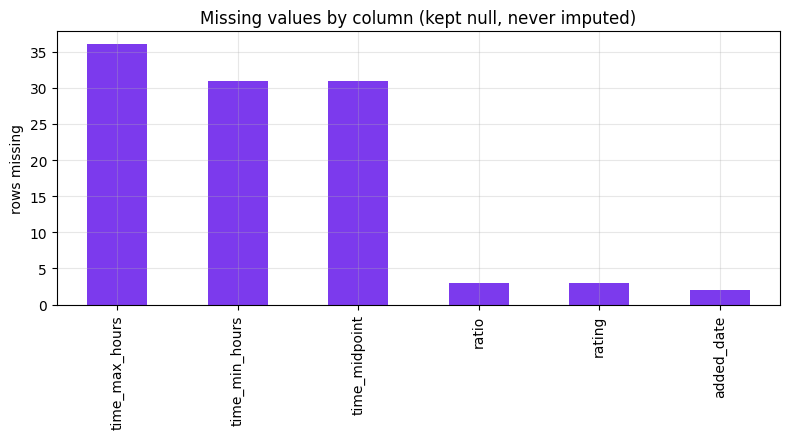

In [5]:
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
print(miss)
ax = miss.plot(kind="bar", color="#7c3aed")
ax.set_title("Missing values by column (kept null, never imputed)")
ax.set_ylabel("rows missing")
plt.tight_layout(); plt.show()

## 4. RATING distribution

`RATING` is the player-sentiment score. Note the **survivorship skew** — this is a curated
catalog, so ratings cluster high and the spread is narrow. As a quality prior it should be
normalized within the *observed* range and not allowed to dominate.

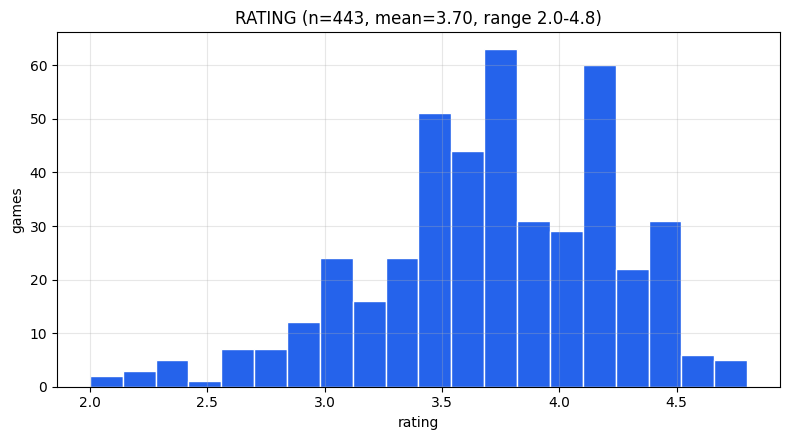

count    443.000000
mean       3.702257
std        0.516816
min        2.000000
25%        3.400000
50%        3.700000
75%        4.100000
max        4.800000
Name: rating, dtype: float64

In [6]:
r = df["rating"].dropna()
fig, ax = plt.subplots()
ax.hist(r, bins=20, color="#2563eb", edgecolor="white")
ax.set_title(f"RATING (n={len(r)}, mean={r.mean():.2f}, range {r.min()}-{r.max()})")
ax.set_xlabel("rating"); ax.set_ylabel("games")
plt.tight_layout(); plt.show()
r.describe()

## 5. Playtime & the session-length signal

Playtime spans *minutes* to *open-ended epics* (`1000+`). For situational vibes
("after work" -> short), session-length matching needs clean buckets and an explicit
**unknown** bucket for rows without a midpoint.


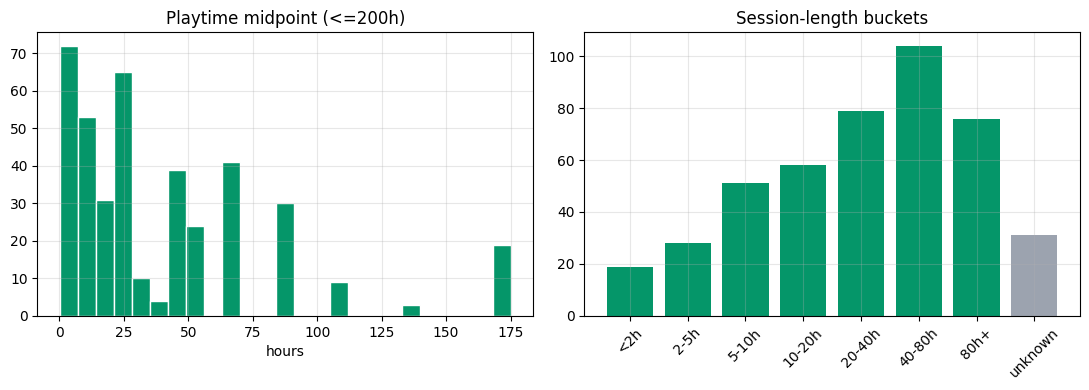

time_midpoint
<2h        19
2-5h       28
5-10h      51
10-20h     58
20-40h     79
40-80h    104
80h+       76
unknown: 31


In [7]:
mid = df["time_midpoint"].dropna()
labels = ["<2h", "2-5h", "5-10h", "10-20h", "20-40h", "40-80h", "80h+"]
bins = [0, 2, 5, 10, 20, 40, 80, 1e9]
bucket = pd.cut(df["time_midpoint"], bins=bins, labels=labels, right=False)
counts = bucket.value_counts().reindex(labels).fillna(0).astype(int)
unknown = int(df["time_midpoint"].isna().sum())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(mid[mid <= 200], bins=25, color="#059669", edgecolor="white")
axes[0].set_title("Playtime midpoint (<=200h)"); axes[0].set_xlabel("hours")
cats = labels + ["unknown"]
vals = list(counts.values) + [unknown]
colors = ["#059669"] * len(labels) + ["#9ca3af"]
axes[1].bar(cats, vals, color=colors)
axes[1].set_title("Session-length buckets")
for t in axes[1].get_xticklabels():
    t.set_rotation(45)
plt.tight_layout(); plt.show()
print(counts.to_string()); print("unknown:", unknown)

## 6. Popularity (GAMERS) is heavy-tailed -> use log scale

A handful of blockbusters dwarf everything. In **linear** space popularity would swamp the
score; `log10(gamers)` compresses the tail enough to use popularity as a soft prior instead
of a dominant feature.


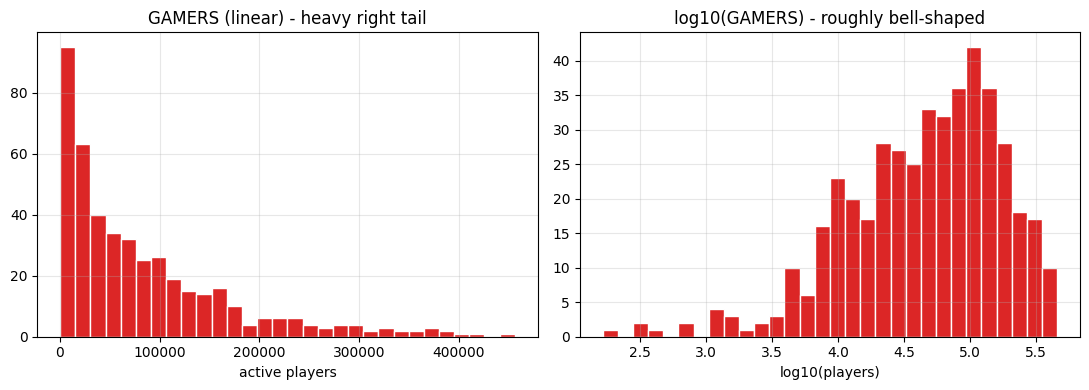

count       446.0
mean      84718.0
std       88876.0
min           0.0
25%       18539.0
50%       52908.0
75%      119198.0
max      455839.0
Name: gamers, dtype: float64

In [8]:
g = df["gamers"].fillna(0)
nonzero = g[g > 0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(nonzero, bins=30, color="#dc2626", edgecolor="white")
axes[0].set_title("GAMERS (linear) - heavy right tail"); axes[0].set_xlabel("active players")
axes[1].hist(np.log10(nonzero), bins=30, color="#dc2626", edgecolor="white")
axes[1].set_title("log10(GAMERS) - roughly bell-shaped"); axes[1].set_xlabel("log10(players)")
plt.tight_layout(); plt.show()
df["gamers"].describe().round(0)

## 7. Does COMP % measure *quality* or *length*?

The original plan used `completion_pct` as a **quality** prior. We test both Pearson
(linear sensitivity) and Spearman (rank/monotonic sensitivity). If completion tracks game
length/difficulty rather than how good a game is, it should be negatively associated with
playtime/grind and only weakly associated with rating; in that case it belongs in the
session/commitment signal, not the quality term.


Correlations (pairwise-complete):
comparison                         pearson  spearman     n
completion% vs playtime             -0.206    -0.644   415
completion% vs rating               -0.022    +0.101   443
completion% vs ratio (grind)        -0.341    -0.854   443
rating vs log10(gamers)             +0.353    +0.362   443
ratio vs playtime                   +0.304    +0.507   415


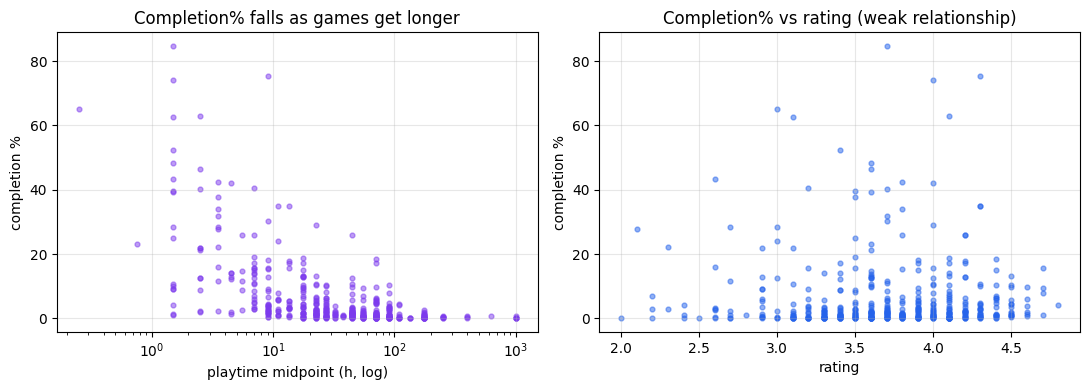

In [9]:
def corr(a, b, method="pearson", logb=False, loga=False):
    # Pairwise-complete: drop rows where EITHER column is missing, so each correlation uses
    # the most data available for that specific pair. n varies, so we return it too.
    sub = df[[a, b]].dropna().copy()
    if loga:  # optionally log-scale a column first (popularity is heavy-tailed; see §6)
        sub = sub[sub[a] > 0]
        sub[a] = np.log10(sub[a])
    if logb:
        sub = sub[sub[b] > 0]
        sub[b] = np.log10(sub[b])
    if method == "spearman":  # rank corr: catches monotonic-but-nonlinear relationships
        return sub[a].rank().corr(sub[b].rank()), len(sub)
    return sub[a].corr(sub[b]), len(sub)  # Pearson: strength of the *linear* association


# Each tuple: (label, (col_a, col_b), kwargs). We compare completion% against the other
# signals to decide whether it measures *quality* or just *length/grind*.
checks = [
    ("completion% vs playtime",      ("completion_pct", "time_midpoint"), {}),
    ("completion% vs rating",        ("completion_pct", "rating"),        {}),
    ("completion% vs ratio (grind)", ("completion_pct", "ratio"),         {}),
    ("rating vs log10(gamers)",      ("rating", "gamers"),                {"logb": True}),
    ("ratio vs playtime",            ("ratio", "time_midpoint"),          {}),
]

# Print Pearson and Spearman side by side: if they disagree, the relationship is nonlinear.
print("Correlations (pairwise-complete):")
print(f"{'comparison':32} {'pearson':>9} {'spearman':>9} {'n':>5}")
for name, (a, b), kw in checks:
    pearson, n = corr(a, b, method="pearson", **kw)
    spearman, _ = corr(a, b, method="spearman", **kw)
    print(f"{name:32} {pearson:+9.3f} {spearman:+9.3f} {n:5}")

# Visual backup for the two key claims: completion falls with length, but is flat vs rating.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
s1 = df[["completion_pct", "time_midpoint"]].dropna()
axes[0].scatter(s1["time_midpoint"], s1["completion_pct"], s=12, alpha=0.5, color="#7c3aed")
axes[0].set_xscale("log")  # log x so the minutes-to-1000h span is legible
axes[0].set_xlabel("playtime midpoint (h, log)"); axes[0].set_ylabel("completion %")
axes[0].set_title("Completion% falls as games get longer")
s2 = df[["rating", "completion_pct"]].dropna()
axes[1].scatter(s2["rating"], s2["completion_pct"], s=12, alpha=0.5, color="#2563eb")
axes[1].set_xlabel("rating"); axes[1].set_ylabel("completion %")
axes[1].set_title("Completion% vs rating (weak relationship)")
plt.tight_layout(); plt.show()

## 8. Hidden gems (the business goal)

Game Pass wants to **reignite the older catalog**. The useful target is **well-rated /
low-player-count** games, not simply obscure games. We first compute `rating_z - popularity_z`,
then require a rating at or above the catalog's 75th percentile so low-popularity but
mediocre titles cannot rank as gems.


Rating floor: >= 4.1 (top quartile); candidates: 124 of 443 rated games


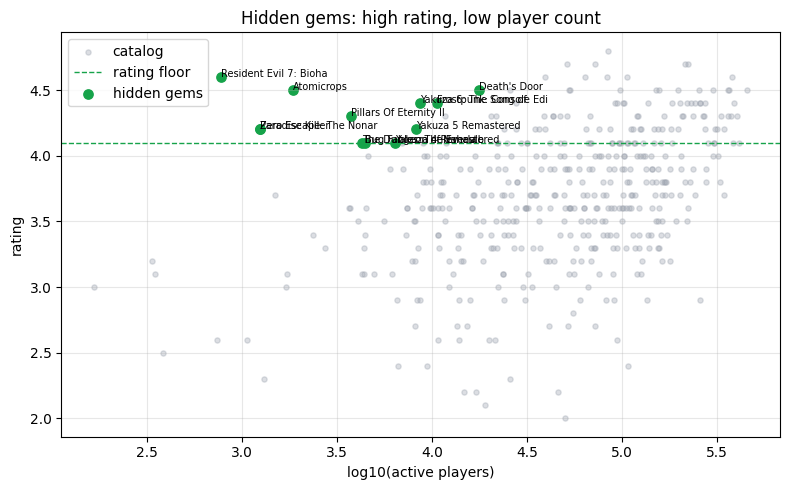

,title,rating,gamers,time_midpoint,ratio
0,Resident Evil 7: Biohazard Grotesque Ver.,4.6,777,17.5,1.58
1,Atomicrops,4.5,1853,NaN,2.90
2,Zero Escape: The Nonary Games,4.2,1250,45.0,1.69
3,Paradise Killer,4.2,1250,13.5,1.57
4,Pillars Of Eternity II: Deadfire,4.3,3728,70.0,2.53
5,Yakuza 6: The Song of Life,4.4,8621,55.0,2.01
6,The Dungeon of Naheulbeuk: The Amulet of Chaos...,4.1,4273,NaN,7.64
7,Bug Fables: The Everlasting Sapling,4.1,4461,45.0,2.70
8,Frostpunk: Console Edition,4.4,10578,175.0,6.05
9,Death's Door,4.5,17756,17.5,1.62


In [10]:
# "Hidden gem" = rated well but under-played. We z-score both axes so they're on a comparable
# scale, then score = rating_z - pop_z (reward high rating, penalize a big player count).
d = df.dropna(subset=["rating"]).copy()
d = d[d["gamers"] > 0]                       # need a real player count to call something obscure
d["log_gamers"] = np.log10(d["gamers"])      # heavy-tailed popularity -> compare in log space
d["rating_z"] = (d["rating"] - d["rating"].mean()) / d["rating"].std()
d["pop_z"] = (d["log_gamers"] - d["log_gamers"].mean()) / d["log_gamers"].std()
d["hidden_gem_score"] = d["rating_z"] - d["pop_z"]

# Quality floor: require a top-quartile rating, so "barely anyone plays it" alone can't make
# a mediocre game look like a gem.
rating_floor = d["rating"].quantile(0.75)
gem_pool = d[d["rating"] >= rating_floor].copy()
gems = gem_pool.sort_values("hidden_gem_score", ascending=False).head(12)

print(f"Rating floor: >= {rating_floor:.1f} (top quartile); candidates: {len(gem_pool)} of {len(d)} rated games")

# Plot the whole catalog, the floor, and the gems we surfaced (labelled).
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(d["log_gamers"], d["rating"], s=14, alpha=0.35, color="#9ca3af", label="catalog")
ax.axhline(rating_floor, color="#16a34a", linewidth=1, linestyle="--", label="rating floor")
ax.scatter(gems["log_gamers"], gems["rating"], s=45, color="#16a34a", label="hidden gems")
for _, row in gems.iterrows():
    ax.annotate(row["title"][:22], (row["log_gamers"], row["rating"]), fontsize=7)
ax.set_xlabel("log10(active players)"); ax.set_ylabel("rating")
ax.set_title("Hidden gems: high rating, low player count")
ax.legend(); plt.tight_layout(); plt.show()
gems[["title", "rating", "gamers", "time_midpoint", "ratio"]].reset_index(drop=True)

## 9. Correlation among metrics

The full correlation matrix is a quick dependency check before blending metrics. It helps
flag which fields are redundant or should be treated as separate signals.


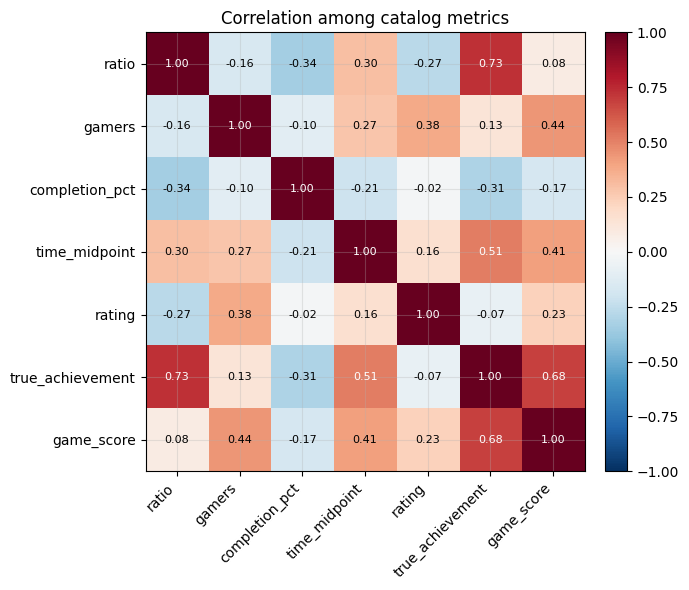

In [11]:
cols = ["ratio", "gamers", "completion_pct", "time_midpoint", "rating",
        "true_achievement", "game_score"]
corr_m = df[cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_m, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = corr_m.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.5 else "black")
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlation among catalog metrics")
plt.tight_layout(); plt.show()

## 10. Grindiest games (high achievement ratio × long playtime)

Powers a fun Insights angle; `ratio` is a grind/difficulty signal, deliberately **kept out**
of core relevance.

In [12]:
grind = df.dropna(subset=["time_midpoint", "ratio"]).copy()
grind = grind.sort_values(["ratio", "time_midpoint"], ascending=False).head(10)
grind[["title", "ratio", "time_midpoint", "completion_pct", "rating"]].reset_index(drop=True)

,title,ratio,time_midpoint,completion_pct,rating
0,I Am Fish,16.46,45.0,0.1,2.7
1,Surgeon Simulator 2,14.55,55.0,0.1,2.0
2,Descenders,12.95,55.0,0.1,3.3
3,Before We Leave,12.53,70.0,0.2,3.4
4,Spelunky 2,12.46,90.0,0.2,3.6
5,Microsoft Flight Simulator,12.32,1000.0,0.0,4.4
6,Unravel Two,11.13,27.5,0.4,3.9
7,ScreamRide,11.08,55.0,0.1,3.1
8,Worms Rumble,10.31,90.0,0.2,2.9
9,Lumines Remastered,9.76,17.5,0.3,3.3


## 11. Catalog additions over time

This snapshot covers Game Pass additions through the source catalog date. The month trend is
useful mostly as context: it shows how much of the recommendation pool is older/back-catalog
content versus recent additions, but it should not be used as a quality signal.


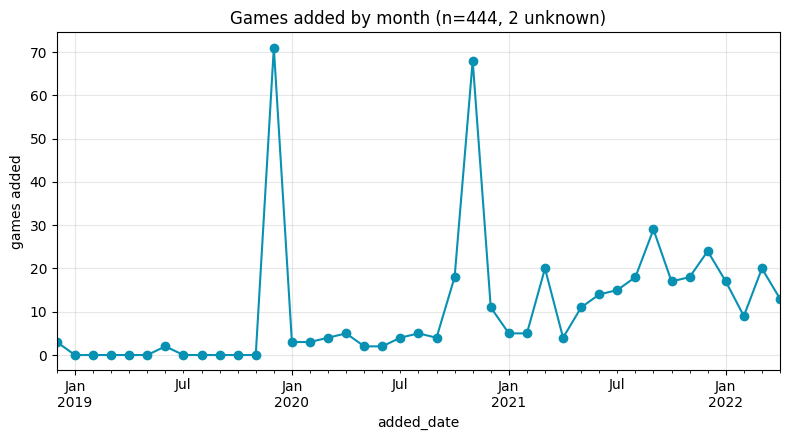

Latest catalog date: 2022-04-28
Older than 12 months: 238 games (53.6%)
Added in last 12 months: 206 games (46.4%)


In [13]:
added = df.dropna(subset=["added_date"]).copy()
by_month = added.set_index("added_date").resample("ME").size()
latest_date = added["added_date"].max()
older_cutoff = latest_date - pd.DateOffset(months=12)
older_count = int((added["added_date"] < older_cutoff).sum())
recent_count = int((added["added_date"] >= older_cutoff).sum())

ax = by_month.plot(kind="line", marker="o", color="#0891b2")
ax.set_title(f"Games added by month (n={len(added)}, {int(df['added_date'].isna().sum())} unknown)")
ax.set_ylabel("games added"); plt.tight_layout(); plt.show()
print(f"Latest catalog date: {latest_date.date()}")
print(f"Older than 12 months: {older_count} games ({older_count / len(added):.1%})")
print(f"Added in last 12 months: {recent_count} games ({recent_count / len(added):.1%})")


## 12. Data limitations

- This is a 2022 catalog snapshot, so availability and player counts may be stale.
- `rating` and `gamers` are platform/community metrics, not universal measures of quality or demand.
- Game Pass is already curated, so the rating distribution has survivorship bias.
- The source has no semantic game descriptors; genre/theme/mood must come from enrichment before vibe matching.
- Relative dates and missing playtimes are preserved as unknowns to avoid false precision.


## Key takeaways -> design implications

1. **Enrichment is mandatory, not optional.** The catalog has *zero* semantic columns;
   vibe matching is impossible without an enriched layer (genres/tags/themes/summary).
2. **`completion_pct` is a completion/commitment signal, not a quality prior.** Pearson is
   near zero vs rating, and Spearman shows strong monotonic relationships with playtime and
   grind. Move it out of the quality term.
3. **Log-scale `gamers`** as the popularity prior. Raw counts are heavy-tailed and would
   swamp the blend.
4. **`rating` is narrow and survivorship-skewed.** Normalize within the observed range and
   keep it as a soft prior.
5. **Treat missing playtime/rating as neutral or unknown.** Do not impute; session-length
   matching needs an explicit unknown path.
6. **Hidden gems need a quality floor.** Use high rating plus low popularity; obscurity
   alone is not enough.
7. **`ratio` = grind/difficulty**, useful for flavor/insights but kept out of core relevance ranking.
